In [1]:
import numpy as np
import goes2go as goes
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from matplotlib import animation
from IPython import display

In [2]:
data_dir = '../data/train'
meta_path = '../data/train_metadata.csv'

In [3]:
# we first the datamethod in the paper where we just subtract band 15 - band 13 
# and then use that as the input

metadata = pd.read_csv(meta_path)
metadata.head()

,record_id,label
0,7829917977180135058,1
1,5319255125658459358,1
2,5747024955383921098,1
3,432548070956515051,1
4,3727988927537047897,1


In [4]:
# https://www.kaggle.com/code/vibhorsharma111/eda-model-train-submit#EDA

def get_band_images(idx: str, parent_folder: str, band: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'band_{band}.npy'))

def get_mask(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_pixel_masks.npy'))

def get_mask_ind(idx: str, parent_folder: str):
    idx = str(idx)
    return np.load(os.path.join(parent_folder, idx, f'human_individual_masks.npy'))

_T11_BOUNDS = (243, 303)
_CLOUD_TOP_TDIFF_BOUNDS = (-4, 5)
_TDIFF_BOUNDS = (-4, 2)

def normalize_range(data, bounds):
    return (data - bounds[0]) / (bounds[1] - bounds[0])

def fake_color_img(idx, parent_folder, get_mask_frame_only=False):
    
    band11 = get_band_images(idx, parent_folder, '11')
    band14 = get_band_images(idx, parent_folder, '14')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band11 = band11[:,:,4]
        band14 = band14[:,:,4]
        band15 = band15[:,:,4]

    r = normalize_range(band15 - band14, _TDIFF_BOUNDS)
    g = normalize_range(band14 - band11, _CLOUD_TOP_TDIFF_BOUNDS)
    b = normalize_range(band14, _T11_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color


def btd_image(idx, parent_folder, get_mask_frame_only=False):
    
    band13 = get_band_images(idx, parent_folder, '13')
    band15 = get_band_images(idx, parent_folder, '15')
    
    if get_mask_frame_only:
        band13 = band13[:,:,4]
        band15 = band15[:,:,4]

    g = normalize_range(band13 - band15, _CLOUD_TOP_TDIFF_BOUNDS)
    false_color = np.clip(np.stack([r, g, b], axis=2), 0, 1)
    return false_color


Processing 2400 samples...


100%|██████████| 2400/2400 [00:09<00:00, 255.58it/s]


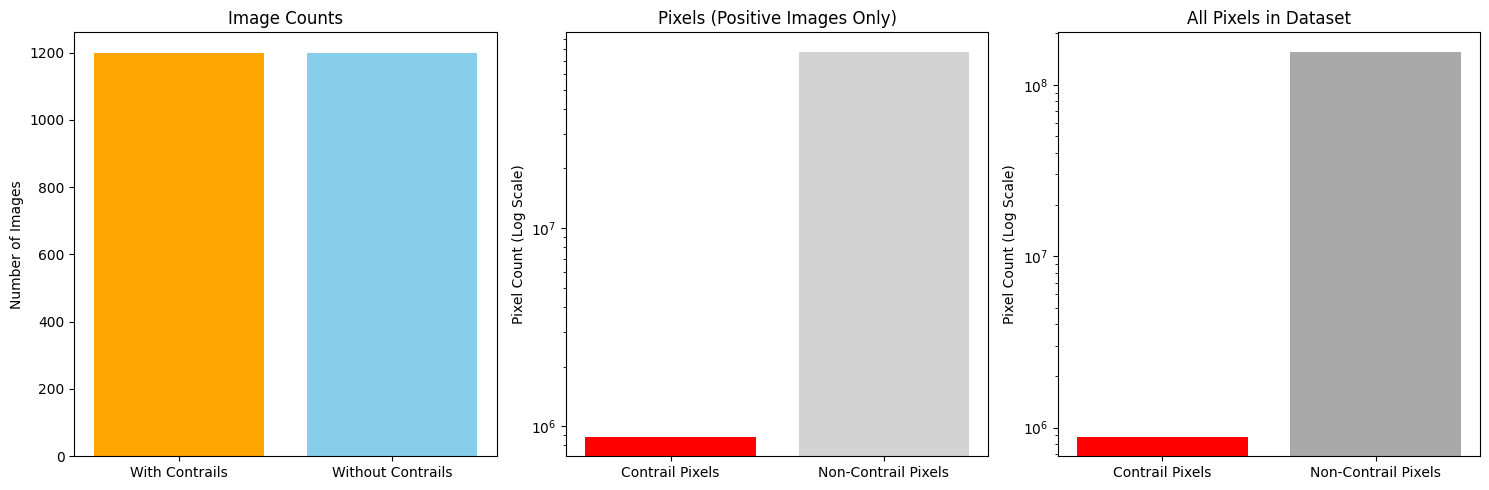


Summary:
Total Images: 2400
Images with Contrails: 1200
Contrail Pixel Ratio (Full Dataset): 0.5604%


In [5]:
from tqdm import tqdm

def analyze_contrail_dataset(parent_folder):
    ids = [d for d in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, d))]
    
    # Counters for Image-level Bar Chart
    with_contrails_count = 0
    without_contrails_count = 0
    
    # Counters for Pixel-level (Only images containing contrails)
    contrail_pixels_in_positive_imgs = 0
    non_contrail_pixels_in_positive_imgs = 0
    
    # Counters for Pixel-level (Full Dataset)
    total_contrail_pixels = 0
    total_non_contrail_pixels = 0

    print(f"Processing {len(ids)} samples...")
    
    for idx in tqdm(ids):
        try:
            # Load the human pixel mask
            mask = get_mask(idx, parent_folder)
            
            num_contrail_pixels = np.sum(mask)
            total_pixels = mask.size
            num_non_contrail_pixels = total_pixels - num_contrail_pixels
            
            # Global Pixel Stats
            total_contrail_pixels += num_contrail_pixels
            total_non_contrail_pixels += num_non_contrail_pixels
            
            if num_contrail_pixels > 0:
                # Image Level
                with_contrails_count += 1
                # Pixel Level (Positive images only)
                contrail_pixels_in_positive_imgs += num_contrail_pixels
                non_contrail_pixels_in_positive_imgs += num_non_contrail_pixels
            else:
                # Image Level
                without_contrails_count += 1
                
        except FileNotFoundError:
            continue

    # --- Plot 1: Num Images With vs Without Contrails ---
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.bar(['With Contrails', 'Without Contrails'], [with_contrails_count, without_contrails_count], color=['orange', 'skyblue'])
    plt.title('Image Counts')
    plt.ylabel('Number of Images')

    # --- Plot 2: Pixels in Positive Images Only ---
    plt.subplot(1, 3, 2)
    plt.bar(['Contrail Pixels', 'Non-Contrail Pixels'], 
            [contrail_pixels_in_positive_imgs, non_contrail_pixels_in_positive_imgs], 
            color=['red', 'lightgrey'])
    plt.title('Pixels (Positive Images Only)')
    plt.yscale('log') # Log scale usually helps as non-contrail pixels vastly outnumber others
    plt.ylabel('Pixel Count (Log Scale)')

    # --- Plot 3: All Pixels in Dataset ---
    plt.subplot(1, 3, 3)
    plt.bar(['Contrail Pixels', 'Non-Contrail Pixels'], 
            [total_contrail_pixels, total_non_contrail_pixels], 
            color=['red', 'darkgrey'])
    plt.title('All Pixels in Dataset')
    plt.yscale('log')
    plt.ylabel('Pixel Count (Log Scale)')

    plt.tight_layout()
    plt.show()

    # Print summary text
    print(f"\nSummary:")
    print(f"Total Images: {len(ids)}")
    print(f"Images with Contrails: {with_contrails_count}")
    print(f"Contrail Pixel Ratio (Full Dataset): {100 * total_contrail_pixels / (total_contrail_pixels + total_non_contrail_pixels):.4f}%")

analyze_contrail_dataset(data_dir)

610


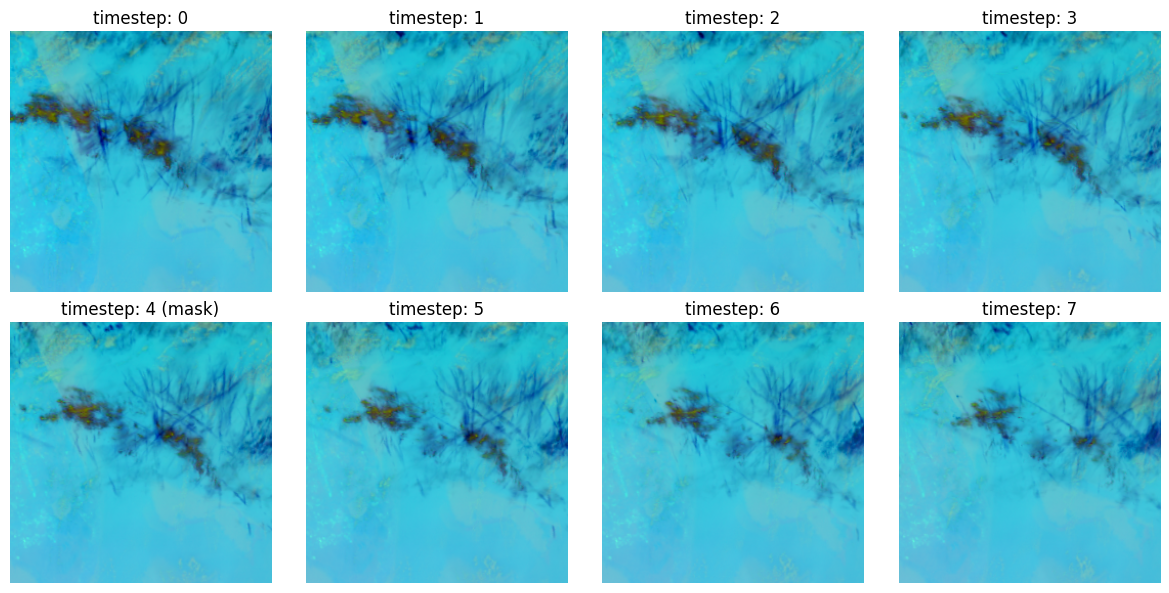

In [16]:
idx = random.randint(0, len(metadata)-1)
print(idx)
record_id = metadata.loc[idx]['record_id']
example_img = fake_color_img(record_id, data_dir)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(example_img[:, :, :, i])
    if i == 4: 
        ax.set_title(f'timestep: {i} (mask)')
    else:
        ax.set_title(f'timestep: {i}')
    ax.axis('off')
    
fig.tight_layout()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

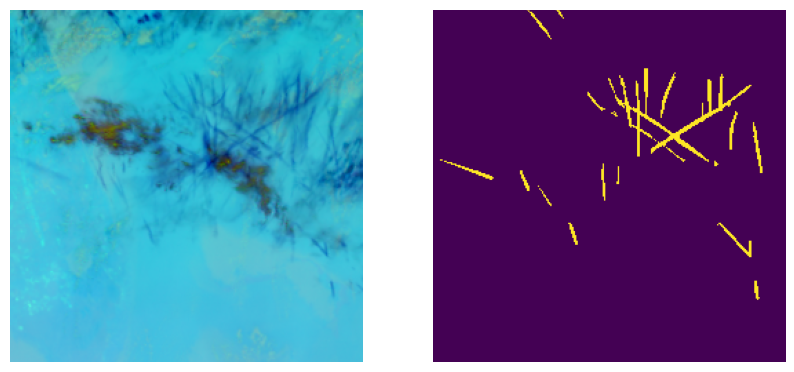

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(example_img[:, :, :, 4])
axes[0].axis('off')
axes[1].imshow(get_mask(record_id, data_dir))
axes[1].axis('off')

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_axis_off()
im = plt.imshow(example_img[..., 0])
def draw(i):
    im.set_array(example_img[..., i])
    return [im]
anim = animation.FuncAnimation(
    fig, draw, frames=example_img.shape[-1], interval=500, blit=True
)
plt.close()
display.HTML(anim.to_jshtml())


In [19]:
import h5py
import gc

# 1. Force the garbage collector to find unreferenced objects
gc.collect()

# 2. Try to catch and close any open H5 files in the local scope
# Note: This is a 'safety' loop
for obj in gc.get_objects():
    try:
        if isinstance(obj, h5py.File):
            obj.close()
            print("Closed a lingering H5 file handle.")
    except:
        pass

In [20]:
import os
import h5py
import numpy as np
from tqdm import tqdm

def create_raw_contrail_h5(data_dir, output_h5, record_ids):
    print(f"Creating {output_h5} with {len(record_ids)} records...")
    
    # Use 'a' (Append) so you can resume if the script stops
    with h5py.File(data_dir + output_h5, 'a', ) as f:
        for rid in tqdm(record_ids):
            # Skip if already in the file
            if rid in f:
                continue
            
            try:
                # 1. Load Raw Infrared Bands
                img_stack = fake_color_img(rid, data_dir)

                # 2. Load Masks
                # individual_masks is usually (256, 256, 6)
                indiv_masks = np.load(os.path.join(data_dir, rid, "human_individual_masks.npy"))
                # pixel_mask is (256, 256, 1)
                pixel_mask = np.load(os.path.join(data_dir, rid, "human_pixel_masks.npy"))

                # 3. Create Group and Datasets
                group = f.create_group(rid)
                
                # Using 'lzf' compression: it's nearly instant and 
                # significantly reduces the 5GB+ file size.
                group.create_dataset("image", data=img_stack, compression="lzf", chunks=(256, 256, 3, 8))
                group.create_dataset("individual_masks", data=indiv_masks, compression="lzf", chunks=(256, 256, 1, 4))
                group.create_dataset("pixel_mask", data=pixel_mask, compression="lzf", chunks=(256, 256, 1))
                
            except FileNotFoundError:
                print(f"Skipping {rid}: Files not found.")
            except Exception as e:
                print(f"Error on {rid}: {e}")

# Example Usage:
# my_record_ids = [folder for folder in os.listdir('/kaggle/input/train')]
# create_raw_contrail_h5('/kaggle/input/train', 'contrails_dataset.h5', my_record_ids)

In [21]:
create_raw_contrail_h5(data_dir, 'train_dataset.h5', metadata['record_id'].astype(str))

Creating train_dataset.h5 with 2400 records...


  0%|          | 7/2400 [00:00<05:15,  7.58it/s]


KeyboardInterrupt: 

In [ ]:
%%time
file = h5py.File('train_dataset.h5', 'r')

CPU times: total: 0 ns
Wall time: 652 μs


In [24]:
import os
import h5py
import numpy as np
from tqdm import tqdm

def create_fakeimgs(data_dir, record_ids):
    print(f"Creating fake imgs...")
   
    for rid in tqdm(record_ids):        
        try:
            img_stack = fake_color_img(rid, data_dir)
            np.save(data_dir + '/' + rid + '/ash_color_img.npy', img_stack)
            
        except FileNotFoundError:
            print(f"Skipping {rid}: Files not found.")
        except Exception as e:
            print(f"Error on {rid}: {e}")

# Example Usage:
# my_record_ids = [folder for folder in os.listdir('/kaggle/input/train')]
# create_raw_contrail_h5('/kaggle/input/train', 'contrails_dataset.h5', my_record_ids)

In [25]:
create_fakeimgs(data_dir, metadata['record_id'].astype(str))

Creating fake imgs...


100%|██████████| 2400/2400 [04:29<00:00,  8.89it/s]


In [26]:
def get_ash_image(idx: str, parent_folder: str = data_dir, get_mask_only: bool = False):
    idx = str(idx)
    img = np.load(os.path.join(parent_folder, idx, f'ash_color_img.npy'))
    return img

In [ ]:
%%time
for i in range(32):
    idx = str(metadata.loc[i]['record_id'])
    img = fake_color_img(idx, data_dir)
    label = get_mask(idx, data_dir)
    ind_mask = get_mask_ind(idx, data_dir)


CPU times: total: 359 ms
Wall time: 796 ms


In [ ]:
%%time
for i in range(32):
    idx = str(metadata.loc[i]['record_id'])
    img = file[idx]['image']
    label = file[idx]['pixel_mask']
    ind_mask = file[idx]['individual_masks']


CPU times: total: 15.6 ms
Wall time: 13.4 ms


In [7]:
import albumentations as A
import cv2

def shift(img):
    shift_matrix = np.array([[1.0, 0.0, 0.5], [0.0, 1.0, 0.5]], dtype=np.float32)

    # Apply the affine transformation using cv2.warpAffine
    shifted_img = cv2.warpAffine(
        img,
        shift_matrix,
        (img.shape[1], img.shape[0]), # Keep the same size
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    return shifted_img.astype(img.dtype)

train_transform = A.Compose([
            # A.Rotate(p=1), 
            A.RandomRotate90(p=1),
            A.OneOf([
                A.HorizontalFlip(p=0.75),
                A.VerticalFlip(p=0.75),
            ], p=1),
            A.Affine(
                scale=(0.9, 1.1),
                rotate=(-90, 90),
                translate_percent={"x": (-0.0, 0.0), "y": (-0.0, 0.0)},
                shear=(-0, 0),
                p=1,
                mask_interpolation=cv2.INTER_NEAREST
            ),
            # A.GaussianBlur(sigma_limit=0.5, p=0.25),
            # A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.15, p=0.3),
        ], additional_targets={'pixel_mask': 'mask', 'soft_mask': 'mask'})

In [18]:
image = shift(example_img[:, :, :, 4])
pixel_mask = get_mask(record_id, data_dir)
soft_mask = get_mask_ind(record_id, data_dir).mean(axis=3)
soft_mask = np.clip((soft_mask * 2).sum(-1) / soft_mask.shape[-1], 0, 1)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

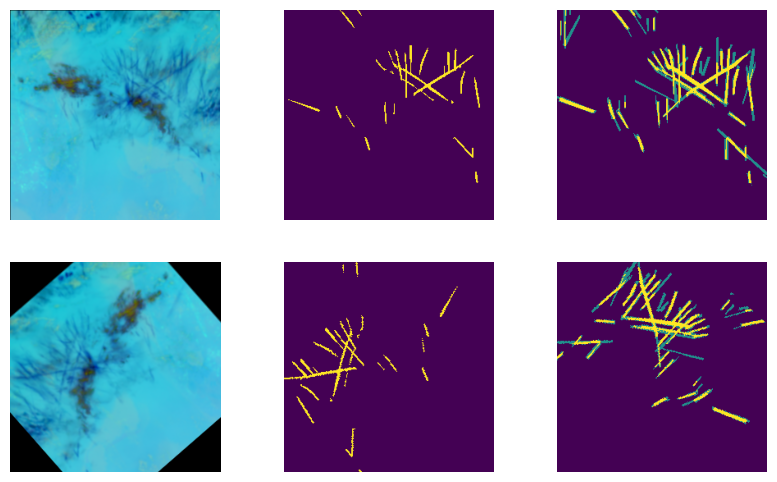

In [20]:
augmented = train_transform(image=image, pixel_mask=pixel_mask, soft_mask=soft_mask)
image_aug = augmented['image']
pixel_mask_aug = augmented['pixel_mask']
soft_mask_aug = augmented['soft_mask']

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes[0, 0].imshow(image)
axes[0, 0].axis('off')
axes[0, 1].imshow(pixel_mask)
axes[0, 1].axis('off')
axes[0, 2].imshow(soft_mask)
axes[0, 2].axis('off')

axes[1, 0].imshow(image_aug)
axes[1, 0].axis('off')
axes[1, 1].imshow(pixel_mask_aug)
axes[1, 1].axis('off')
axes[1, 2].imshow(soft_mask_aug)
axes[1, 2].axis('off')

In [105]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

def check_alignment(image, mask, zoom_box=(100, 100, 50, 50)):
    y, x, h, w = zoom_box
    
    if torch.is_tensor(image):
        image = image.permute(1, 2, 0).cpu().numpy()
    if torch.is_tensor(mask):
        mask = mask.cpu().numpy()

    img_norm = (image - image.min()) / (image.max() - image.min() + 1e-7)
    if img_norm.shape[-1] > 3:
        img_norm = img_norm[:, :, :3]
    
    img_crop = img_norm[y:y+h, x:x+w]
    mask_crop = mask[y:y+h, x:x+w].squeeze()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_crop)
    axes[0].set_title("Zoomed Ash Image")
    
    axes[1].imshow(mask_crop, cmap='gray')
    axes[1].set_title("Zoomed Mask")
    
    axes[2].imshow(img_crop)
    axes[2].contour(mask_crop, colors='red', linewidths=2, levels=[0.5])
    axes[2].set_title("Overlay (Red Contour on Image)")
    
    for ax in axes:
        ax.set_xticks(np.arange(-0.5, w, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, h, 1), minor=True)
        ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5, alpha=0.3)
        
    plt.tight_layout()
    return fig

def verify_augmentation_alignment(train_transform, image, pixel_mask, soft_mask):
    pixel_mask = pixel_mask.astype(np.float32)
    soft_mask = soft_mask.astype(np.float32)
    
    transformed = train_transform(
        image=image, 
        pixel_mask=pixel_mask, 
        soft_mask=soft_mask
    )
    
    img_aug = transformed['image']
    p_mask_aug = transformed['pixel_mask']
    s_mask_aug = transformed['soft_mask']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    img_plot = (img_aug - img_aug.min()) / (img_aug.max() - img_aug.min() + 1e-7)
    axes[0].imshow(img_plot[:, :, :3])
    axes[0].set_title("Augmented Image")
    
    axes[1].imshow(p_mask_aug, cmap='gray')
    axes[1].contour(s_mask_aug, colors='cyan', linewidths=1, levels=[0.5], alpha=0.5)
    axes[1].set_title("Pixel Mask (Gray) + Soft Mask (Cyan)")
    
    axes[2].imshow(img_plot[:, :, :3])
    axes[2].contour(p_mask_aug, colors='red', linewidths=1, levels=[0.5])
    axes[2].set_title("Image + Pixel Mask Contour")
    
    plt.tight_layout()
    return fig

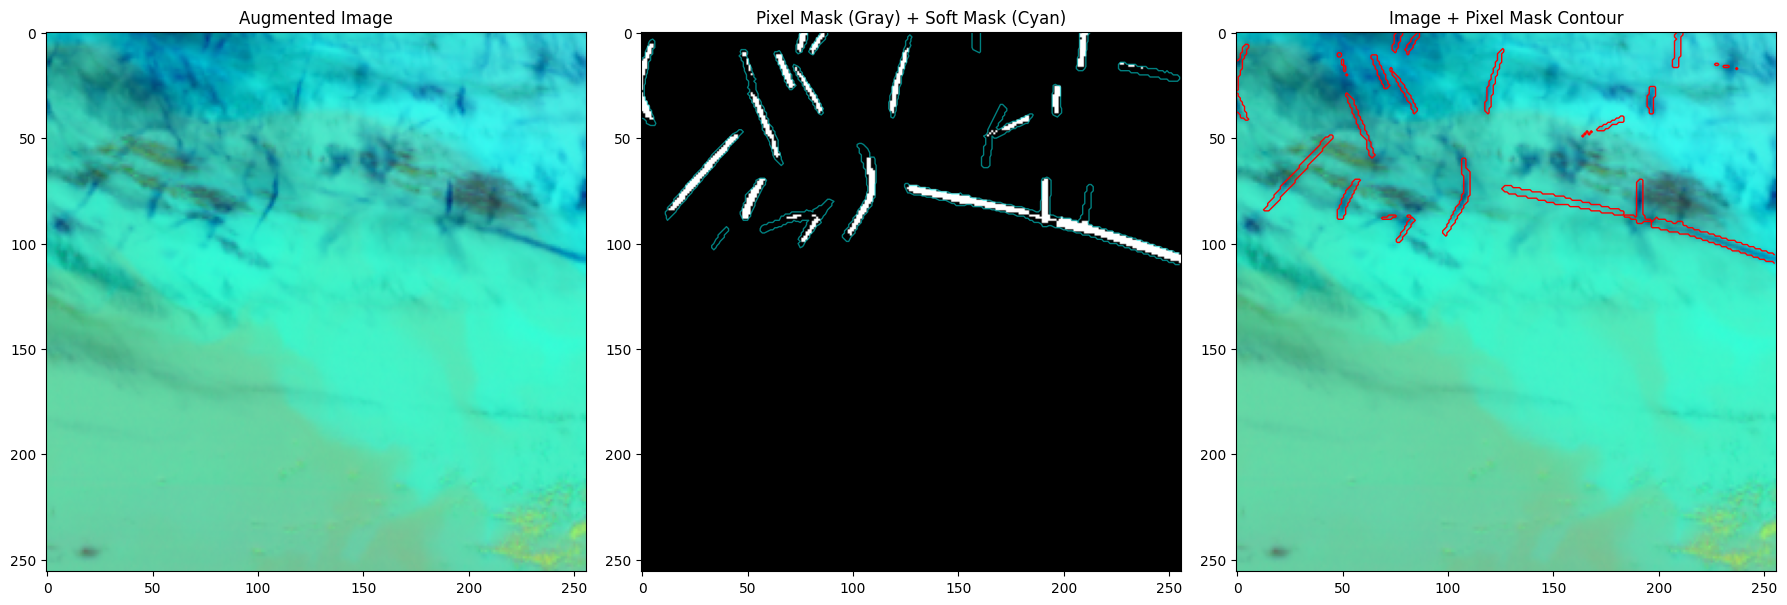

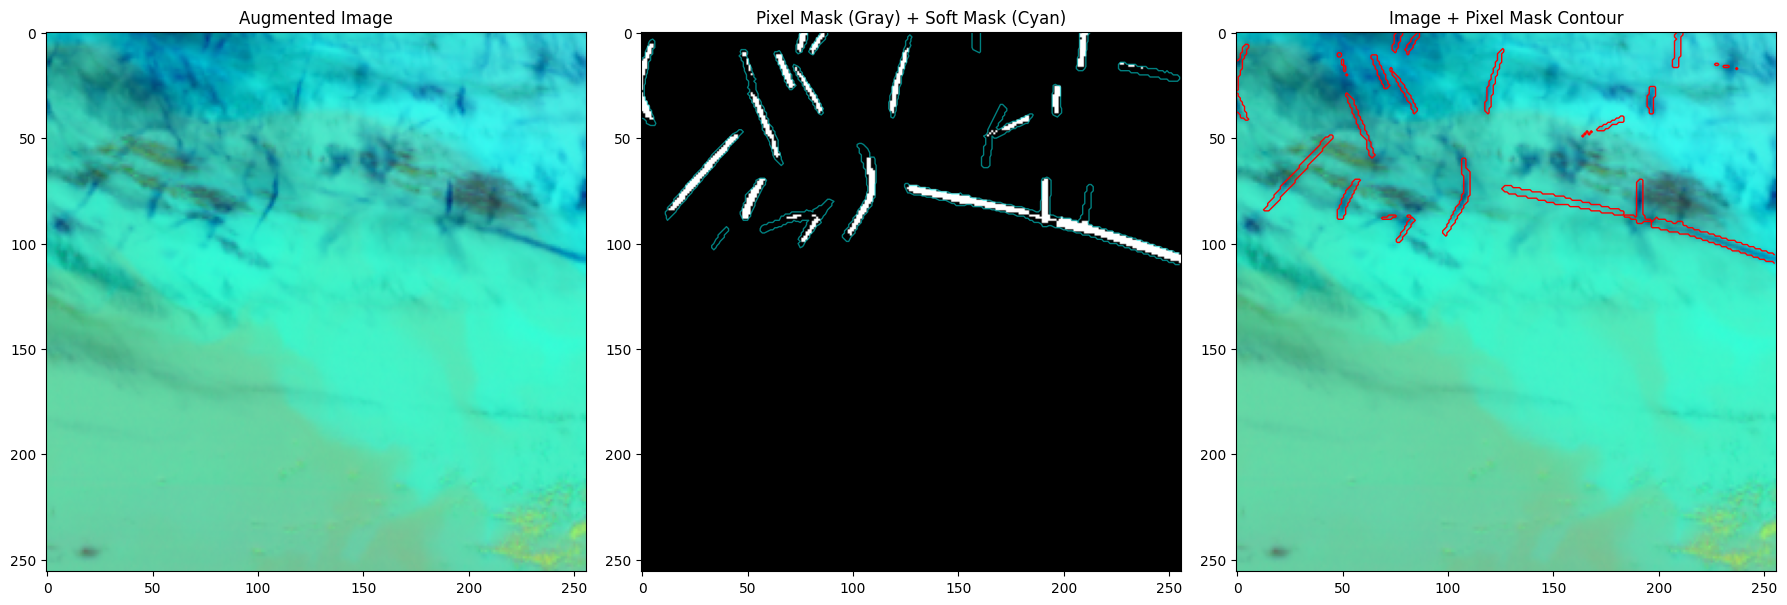

In [106]:
verify_augmentation_alignment(train_transform, image, pixel_mask.squeeze(), soft_mask.squeeze())